## Data Wrangler 2

Nos damos cuenta que sigue existiendo el problema de los missings, aunque reportados anteriormente
se hace un análisis más exahustivo para generar los datos completamente limpios.

In [1]:
"""
Data wrangling secuencial: diagnóstico e imputación de missings
------------------------------------------------------------------
Corre de arriba hacia abajo, celda por celda en tu notebook.
No hay funciones reutilizables a propósito: esto se hace una sola vez.
"""
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from scipy import stats
 
# ---------------------------------------------------------------------------
# ESTILO VISUAL (una sola vez, aplica a todas las gráficas del notebook)
# ---------------------------------------------------------------------------
sns.set_theme(style="whitegrid", font_scale=0.95)
COLOR_BEFORE = "#E8A798"   # coral suave — "antes de imputar"
COLOR_AFTER = "#6FB5A8"    # teal — "después de imputar"
COLOR_MISS = "#8B93E8"     # morado — barras de % de missing
PALETA_GENERO = {"F": "#E63946", "M": "#457B9D"}  # mujeres en rojo, hombres en azul
plt.rcParams["axes.edgecolor"] = "#444444"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.facecolor"] = "white"
 

In [2]:
 # Etiquetas en español SOLO para mostrar en las gráficas — el df conserva
# los nombres de columna originales en inglés, esto no los modifica.
LABELS_ES = {
    "height_cm": "Estatura (cm)",
    "weight_kg": "Peso (kg)",
    "bmi": "IMC",
    "waist_circumference_cm": "Circunf. de cintura (cm)",
    "sit_and_reach_cm": "Flexibilidad (cm)",
    "cross_situp_count": "Abdominales (rep.)",
    "standing_long_jump_cm": "Salto de longitud (cm)",
    "reaction_time_sec": "Tiempo de reacción (s)",
    "body_fat_pct": "% de grasa corporal",
    "vo2max_estimate": "VO2max estimado",
    "grip_strength_left_kg": "Fuerza de agarre izq. (kg)",
    "grip_strength_right_kg": "Fuerza de agarre der. (kg)",
    "relative_grip_strength_pct": "Fuerza de agarre relativa (%)",
}
 
 
# ---------------------------------------------------------------------------
# 1. CARGA DEL DATASET
# ---------------------------------------------------------------------------
df = pd.read_parquet("../Data/processed/fitness_measurements_adult_clean.parquet")
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
 
 

Dataset cargado: 430666 filas, 21 columnas


Identificación de outliers por valores imposibles o extraños dentro de la muestra

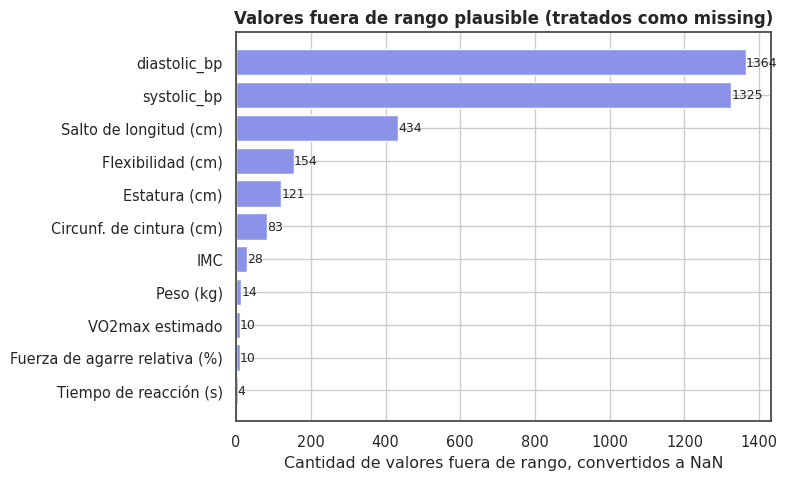


Se convirtieron a NaN valores fuera de rango en 11 columna(s):
diastolic_bp                  1364
systolic_bp                   1325
standing_long_jump_cm          434
sit_and_reach_cm               154
height_cm                      121
waist_circumference_cm          83
bmi                             28
weight_kg                       14
vo2max_estimate                 10
relative_grip_strength_pct      10
reaction_time_sec                4
dtype: int64

Estos NaN nuevos se resuelven más abajo, en las mismas secciones de imputación (mediana por género o MICE), junto con los missings originales.


In [3]:

# ---------------------------------------------------------------------------
# 1.5 CAPEO DE VALORES PLAUSIBLES (antes de calcular missings o imputar)
# ---------------------------------------------------------------------------
# Rangos razonables para un adulto, basados en fisiología del ejercicio y
# sentido común clínico. Ajusta estos límites si tienes un criterio distinto
# (ej. si tu profesor te sugiere otros rangos de referencia).

RANGOS_PLAUSIBLES = {
    "age": (18, 90),
    "height_cm": (140, 210),
    "weight_kg": (30, 200),
    "bmi": (12, 55),
    "waist_circumference_cm": (50, 150),
    "systolic_bp": (70, 240),
    "diastolic_bp": (40, 140),
    "grip_strength_left_kg": (0, 100),
    "grip_strength_right_kg": (0, 100),
    "relative_grip_strength_pct": (0, 150),
    "sit_and_reach_cm": (-20, 45),
    "cross_situp_count": (0, 100),
    "standing_long_jump_cm": (50, 350),
    "reaction_time_sec": (0.05, 2.0),
    "vo2max_estimate": (10, 75),
}
 
conteo_invalidados = {}
for col, (lo, hi) in RANGOS_PLAUSIBLES.items():
    if col not in df.columns:
        continue
    fuera_de_rango = ((df[col] < lo) | (df[col] > hi)) & df[col].notna()
    conteo_invalidados[col] = int(fuera_de_rango.sum())
    df.loc[fuera_de_rango, col] = np.nan  # se tratan como missing, no como capeo
 
resumen_invalidados = pd.Series(conteo_invalidados).sort_values(ascending=False)
resumen_invalidados = resumen_invalidados[resumen_invalidados > 0]
 
if len(resumen_invalidados) > 0:
    etiquetas_invalidados = [LABELS_ES.get(c, c) for c in resumen_invalidados.index]
    plt.figure(figsize=(8, max(3, 0.45 * len(resumen_invalidados))))
    bars = plt.barh(etiquetas_invalidados, resumen_invalidados.values, color=COLOR_MISS, edgecolor="white")
    for bar, val in zip(bars, resumen_invalidados.values):
        plt.text(val + 0.3, bar.get_y() + bar.get_height() / 2, f"{val}", va="center", fontsize=9)
    plt.xlabel("Cantidad de valores fuera de rango, convertidos a NaN")
    plt.title("Valores fuera de rango plausible (tratados como missing)", fontsize=12)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    print(f"\nSe convirtieron a NaN valores fuera de rango en {len(resumen_invalidados)} columna(s):")
    print(resumen_invalidados)
    print("\nEstos NaN nuevos se resuelven más abajo, en las mismas secciones de imputación "
          "(mediana por género o MICE), junto con los missings originales.")
else:
    print("\nNo se encontraron valores fuera de los rangos plausibles definidos — nada que invalidar.")
 
 

Se identifican alrededor de 3k valores atipicos, menos del 1% del dataset

Se identifican los missings por columna para ver si se puede realizar una imputación robusta

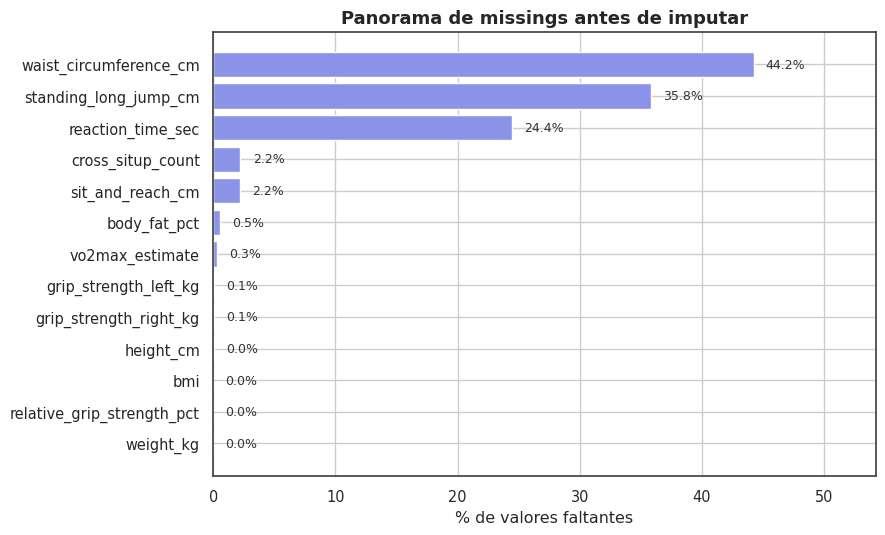

In [4]:
# ---------------------------------------------------------------------------
# 2. PANORAMA GENERAL DE MISSINGS 
# ---------------------------------------------------------------------------
core_cols = [
    "height_cm", "weight_kg", "bmi", "waist_circumference_cm",
    "sit_and_reach_cm", "cross_situp_count", "standing_long_jump_cm",
    "reaction_time_sec", "body_fat_pct", "vo2max_estimate",
    "grip_strength_left_kg", "grip_strength_right_kg", "relative_grip_strength_pct",
]
 
missing_before = (df[core_cols].isna().mean() * 100).sort_values(ascending=False)
 
plt.figure(figsize=(9, 5.5))
bars = plt.barh(missing_before.index, missing_before.values, color=COLOR_MISS, edgecolor="white")
for bar, val in zip(bars, missing_before.values):
    plt.text(val + 1, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%",
              va="center", fontsize=9, color="#333333")
plt.xlabel("% de valores faltantes")
plt.title("Panorama de missings antes de imputar", fontsize=13)
plt.xlim(0, max(missing_before.values) + 10)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Existen variables con alto contenido de missings, por lo que vale la pena atacar de diferente manera a los que tienen mayor cantidad de missings.

/tmp/ipykernel_8632/3493563581.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby("gender_code")[col].transform(lambda s: s.fillna(s.median()))


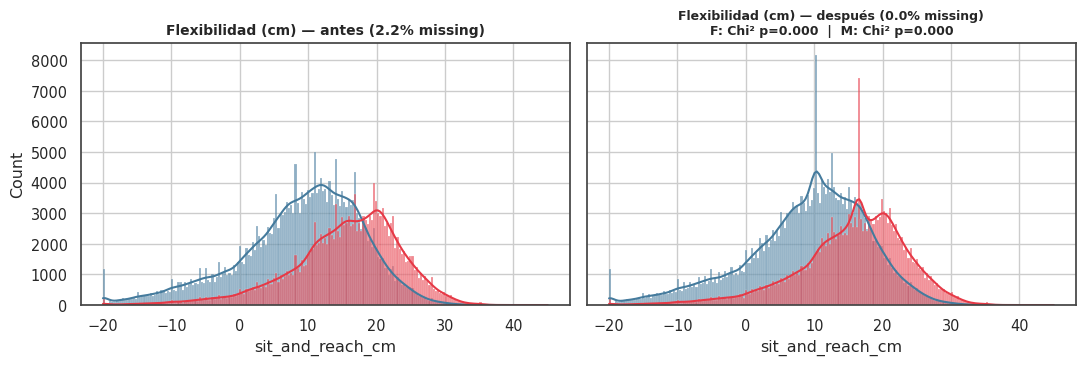

/tmp/ipykernel_8632/3493563581.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby("gender_code")[col].transform(lambda s: s.fillna(s.median()))


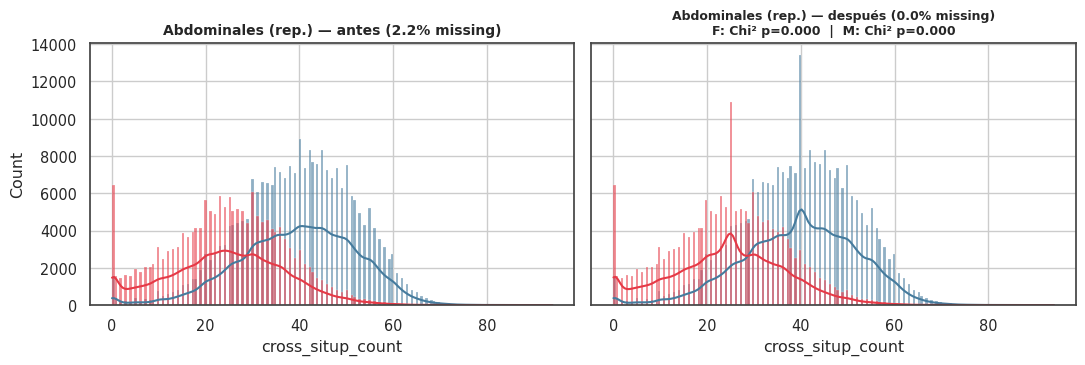

/tmp/ipykernel_8632/3493563581.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby("gender_code")[col].transform(lambda s: s.fillna(s.median()))
/tmp/ipykernel_8632/3493563581.py:43: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_result = stats.anderson_ksamp([valores_antes_g, valores_despues_g])


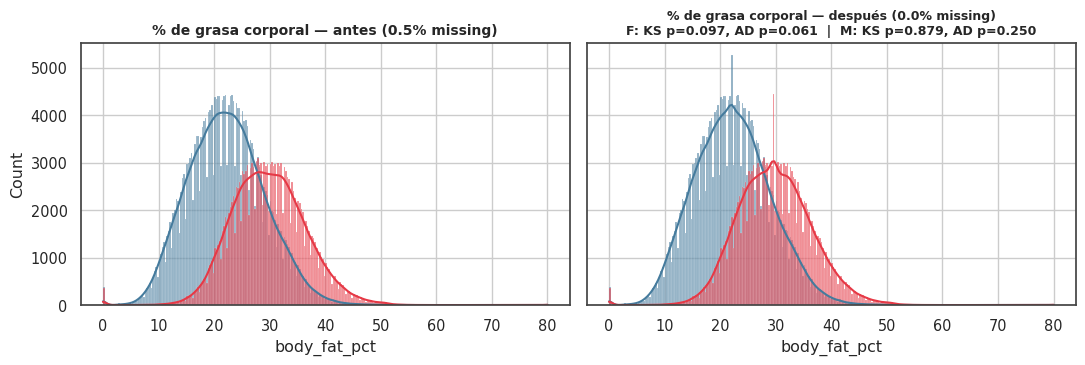

/tmp/ipykernel_8632/3493563581.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby("gender_code")[col].transform(lambda s: s.fillna(s.median()))
/tmp/ipykernel_8632/3493563581.py:43: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_result = stats.anderson_ksamp([valores_antes_g, valores_despues_g])


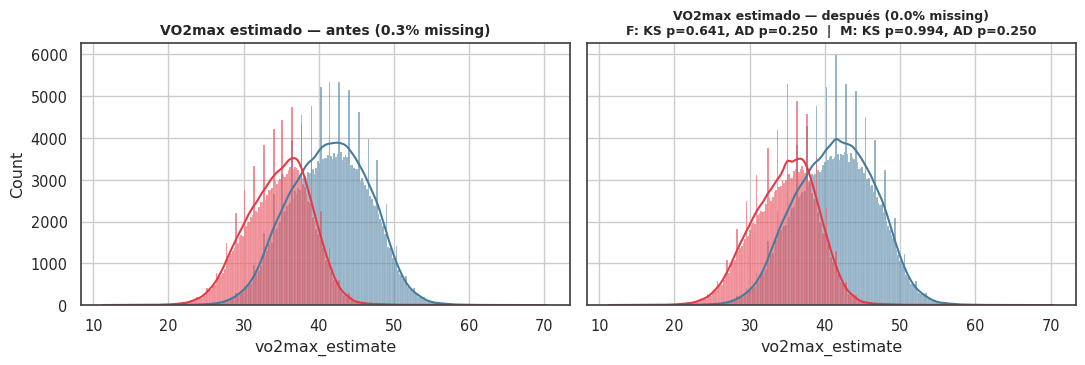

/tmp/ipykernel_8632/3493563581.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby("gender_code")[col].transform(lambda s: s.fillna(s.median()))
/tmp/ipykernel_8632/3493563581.py:43: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_result = stats.anderson_ksamp([valores_antes_g, valores_despues_g])


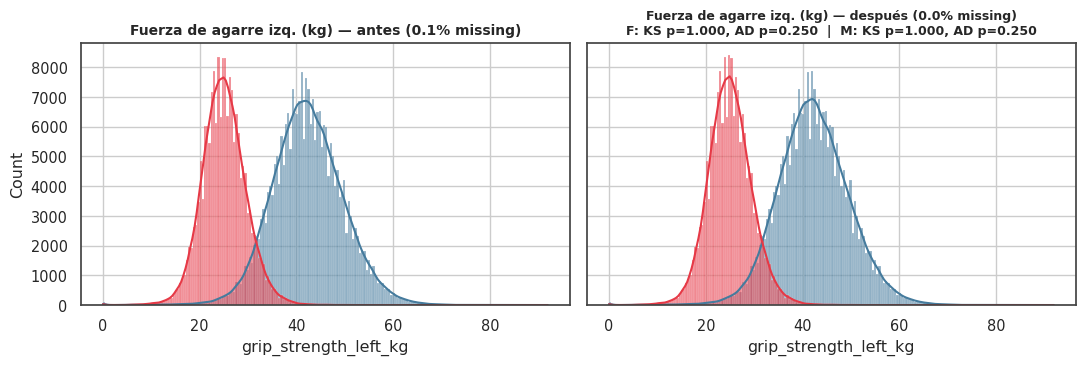

/tmp/ipykernel_8632/3493563581.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby("gender_code")[col].transform(lambda s: s.fillna(s.median()))
/tmp/ipykernel_8632/3493563581.py:43: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_result = stats.anderson_ksamp([valores_antes_g, valores_despues_g])


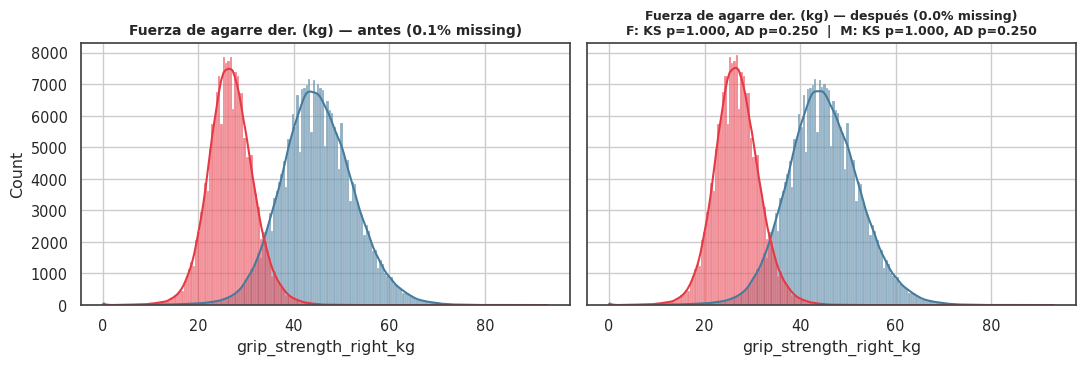

/tmp/ipykernel_8632/3493563581.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby("gender_code")[col].transform(lambda s: s.fillna(s.median()))
/tmp/ipykernel_8632/3493563581.py:43: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_result = stats.anderson_ksamp([valores_antes_g, valores_despues_g])


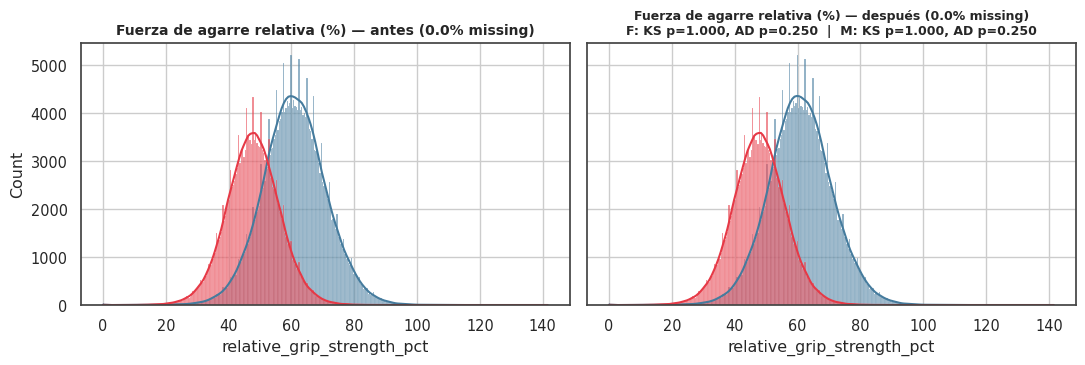

/tmp/ipykernel_8632/3493563581.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby("gender_code")[col].transform(lambda s: s.fillna(s.median()))
/tmp/ipykernel_8632/3493563581.py:43: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_result = stats.anderson_ksamp([valores_antes_g, valores_despues_g])


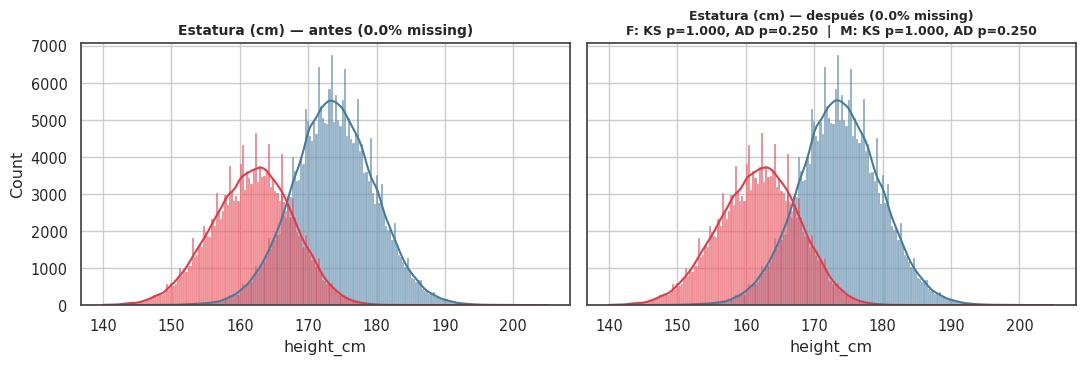

/tmp/ipykernel_8632/3493563581.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby("gender_code")[col].transform(lambda s: s.fillna(s.median()))
/tmp/ipykernel_8632/3493563581.py:43: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_result = stats.anderson_ksamp([valores_antes_g, valores_despues_g])


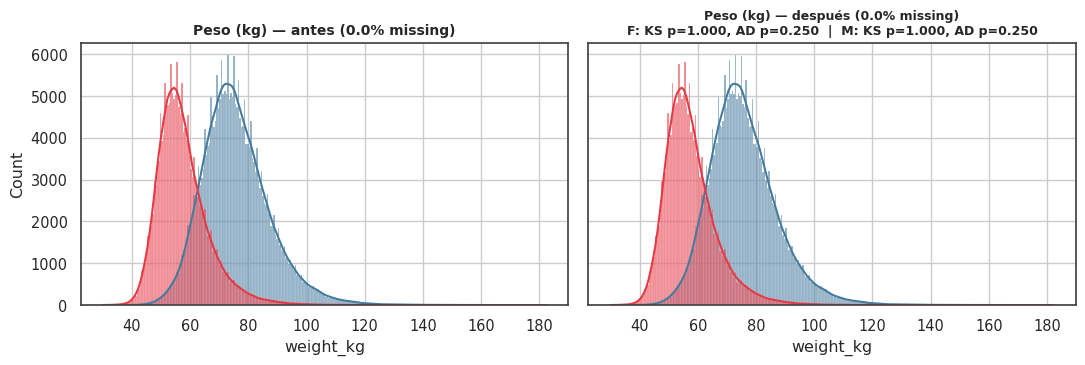

/tmp/ipykernel_8632/3493563581.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby("gender_code")[col].transform(lambda s: s.fillna(s.median()))
/tmp/ipykernel_8632/3493563581.py:43: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_result = stats.anderson_ksamp([valores_antes_g, valores_despues_g])


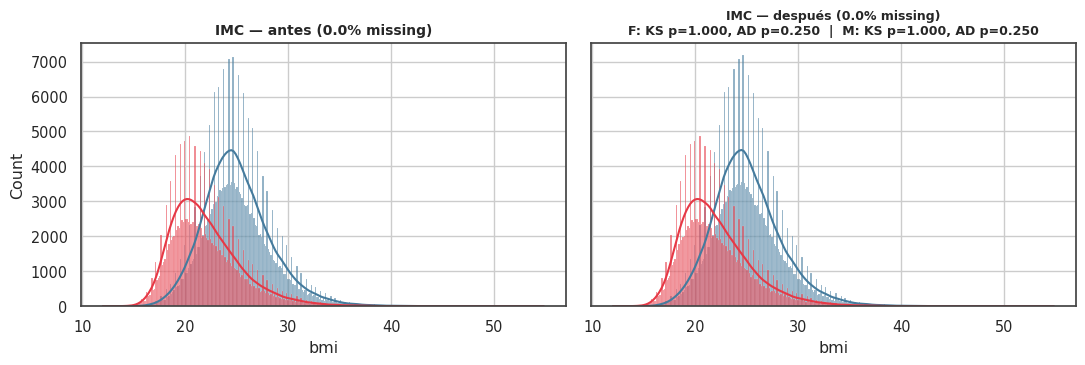

/tmp/ipykernel_8632/3493563581.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby("gender_code")[col].transform(lambda s: s.fillna(s.median()))
/tmp/ipykernel_8632/3493563581.py:43: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_result = stats.anderson_ksamp([valores_antes_g, valores_despues_g])


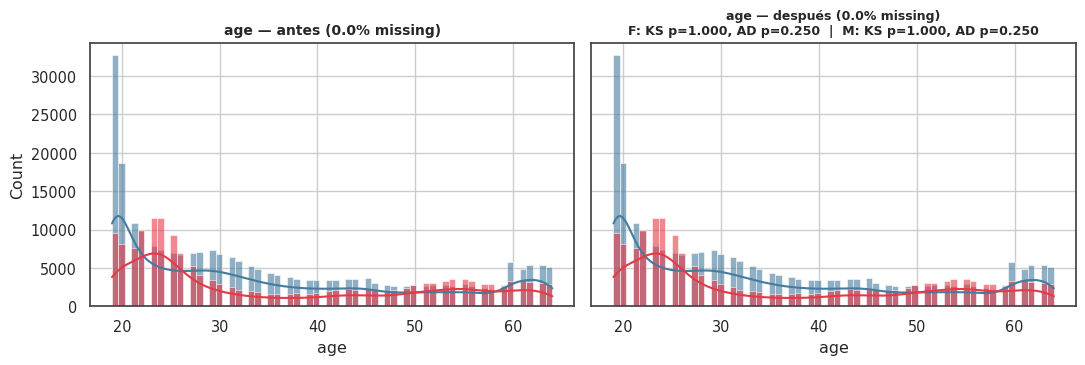

/tmp/ipykernel_8632/3493563581.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby("gender_code")[col].transform(lambda s: s.fillna(s.median()))
/tmp/ipykernel_8632/3493563581.py:43: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_result = stats.anderson_ksamp([valores_antes_g, valores_despues_g])


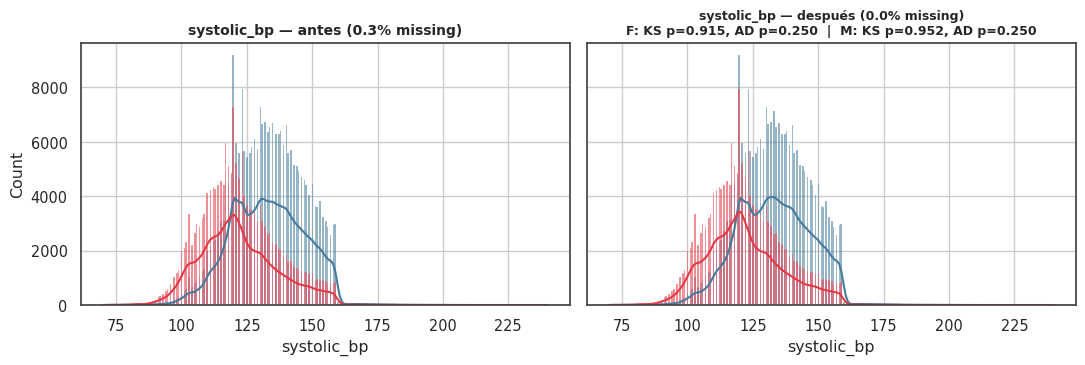

/tmp/ipykernel_8632/3493563581.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby("gender_code")[col].transform(lambda s: s.fillna(s.median()))
/tmp/ipykernel_8632/3493563581.py:43: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_result = stats.anderson_ksamp([valores_antes_g, valores_despues_g])


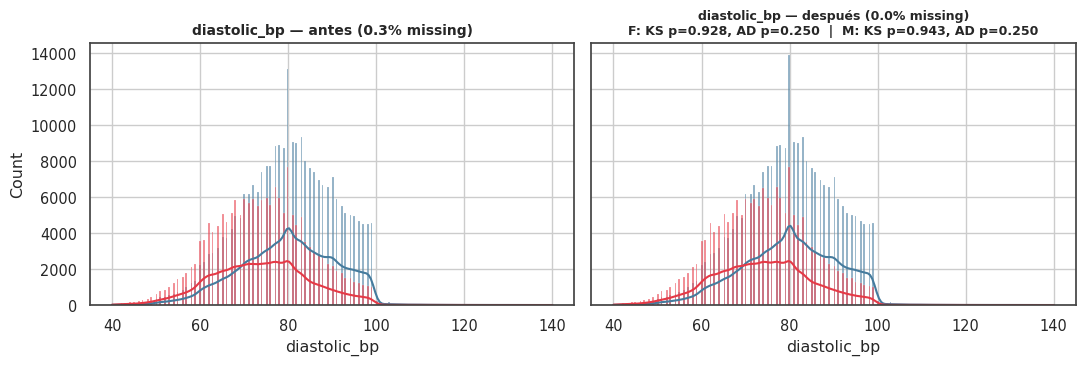

Variables casi completas imputadas con mediana por género.


In [5]:

# ---------------------------------------------------------------------------
# 3. VARIABLES CASI COMPLETAS (<5% missing) — IMPUTACIÓN CON MEDIANA POR GÉNERO
# ---------------------------------------------------------------------------
near_complete_cols = [
    "sit_and_reach_cm", "cross_situp_count", "body_fat_pct", "vo2max_estimate",
    "grip_strength_left_kg", "grip_strength_right_kg", "relative_grip_strength_pct",
    "height_cm", "weight_kg", "bmi", "age", "systolic_bp", "diastolic_bp",
]
 
# Variables discretas de ESTA sección — se les aplica Chi² sí o sí, sin pasar
# por ninguna detección automática. Agrega o quita nombres aquí directamente.
DISCRETAS_SECCION_3 = ["cross_situp_count", "sit_and_reach_cm"]
 
for col in near_complete_cols:
    etiqueta = LABELS_ES.get(col, col)
    snapshot_col = df[[col, "gender_code"]].copy()  # snapshot antes de imputar ESTA columna
    pct_missing = snapshot_col[col].isna().mean() * 100
 
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
 
    sns.histplot(data=snapshot_col, x=col, hue="gender_code", palette=PALETA_GENERO,
                 kde=True, ax=axes[0], alpha=0.6, legend=False)
    axes[0].set_title(f"{etiqueta} — antes ({pct_missing:.1f}% missing)", fontsize=10)
 
    # --- imputación inline, solo para esta columna ---
    df[col] = df.groupby("gender_code")[col].transform(lambda s: s.fillna(s.median()))
 
    # --- pruebas separadas por género (mismo criterio que la sección 5) ---
    resultados_texto = []
    for genero in ["F", "M"]:
        valores_antes_g = snapshot_col.loc[snapshot_col["gender_code"] == genero, col].dropna().values
        valores_despues_g = df.loc[df["gender_code"] == genero, col].values
 
        if col in DISCRETAS_SECCION_3:
            bins = np.histogram_bin_edges(np.concatenate([valores_antes_g, valores_despues_g]), bins=10)
            conteo_antes, _ = np.histogram(valores_antes_g, bins=bins)
            conteo_despues, _ = np.histogram(valores_despues_g, bins=bins)
            tabla = np.array([conteo_antes, conteo_despues]) + 1e-6  # evita ceros en la tabla
            chi2_stat, chi_p, dof, _ = stats.chi2_contingency(tabla)
            resultados_texto.append(f"{genero}: Chi² p={chi_p:.3f}")
        else:
            ks_stat, ks_p = stats.ks_2samp(valores_antes_g, valores_despues_g)
            ad_result = stats.anderson_ksamp([valores_antes_g, valores_despues_g])
            ad_p = ad_result.significance_level
            resultados_texto.append(f"{genero}: KS p={ks_p:.3f}, AD p={ad_p:.3f}")
 
    titulo_prueba = "  |  ".join(resultados_texto)
 
    sns.histplot(data=df, x=col, hue="gender_code", palette=PALETA_GENERO, kde=True, ax=axes[1],
                 alpha=0.6, legend=False)
    axes[1].set_title(
        f"{etiqueta} — después (0.0% missing)\n{titulo_prueba}",
        fontsize=9,
    )
 
    plt.tight_layout()
    plt.show()
 
print("Variables casi completas imputadas con mediana por género.")
 

Observamos que en las variables categóricas al rellenar con la mediana, la prueba de hipotesis sugiere que hubo un cambio en la distribución de los datos, algo no tan grave, solo se reporta

/tmp/ipykernel_8632/3749773127.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  col: df.groupby("measurement_location_type")[col].apply(lambda s: s.isna().mean() * 100)


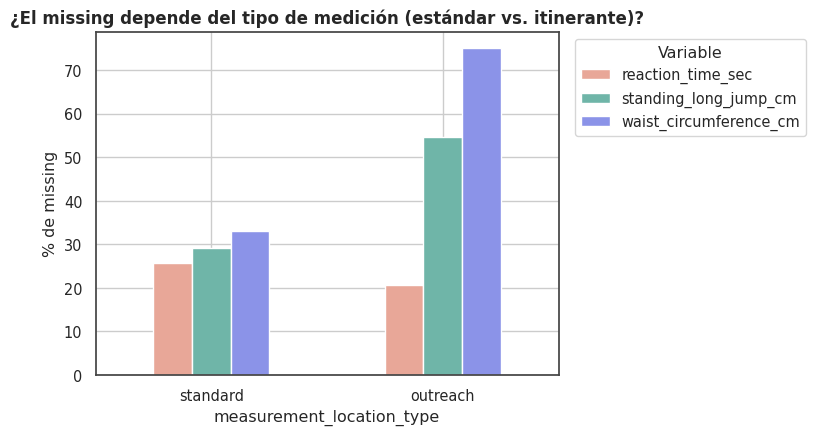

In [6]:
# ---------------------------------------------------------------------------
# 4. VARIABLES CON MISSING ALTO — DIAGNÓSTICO PREVIO
# ---------------------------------------------------------------------------
moderate_cols = ["reaction_time_sec", "standing_long_jump_cm", "waist_circumference_cm"]
 
# ¿El missing depende del tipo de medición (estándar vs. itinerante)?
diag = pd.DataFrame({
    col: df.groupby("measurement_location_type")[col].apply(lambda s: s.isna().mean() * 100)
    for col in moderate_cols
})
 
diag.plot(kind="bar", figsize=(8, 4.5), color=[COLOR_BEFORE, COLOR_AFTER, COLOR_MISS],
          edgecolor="white")
plt.ylabel("% de missing")
plt.title("¿El missing depende del tipo de medición (estándar vs. itinerante)?", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Variable", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
 
 

/tmp/ipykernel_8632/2612042333.py:52: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_result = stats.anderson_ksamp([valores_antes_g, valores_despues_g])


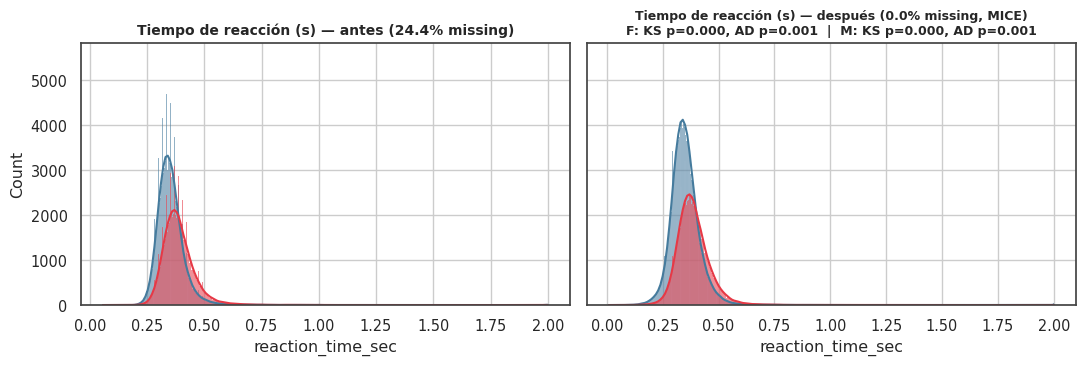

/tmp/ipykernel_8632/2612042333.py:52: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_result = stats.anderson_ksamp([valores_antes_g, valores_despues_g])


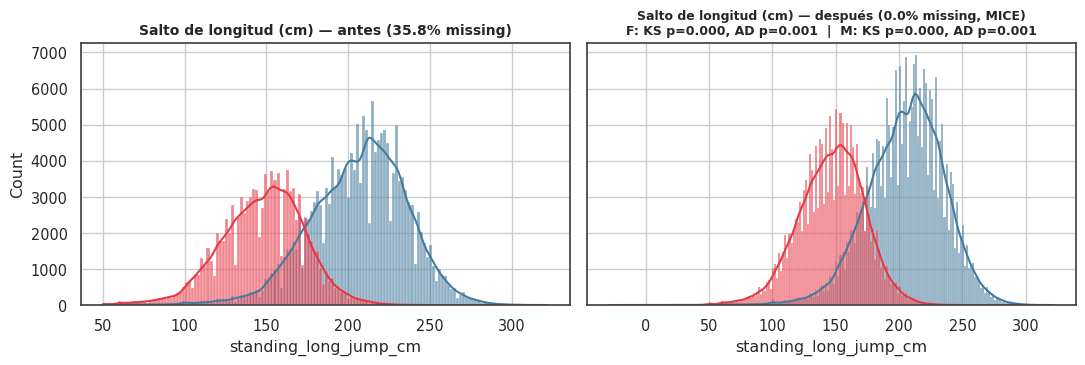

/tmp/ipykernel_8632/2612042333.py:52: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_result = stats.anderson_ksamp([valores_antes_g, valores_despues_g])


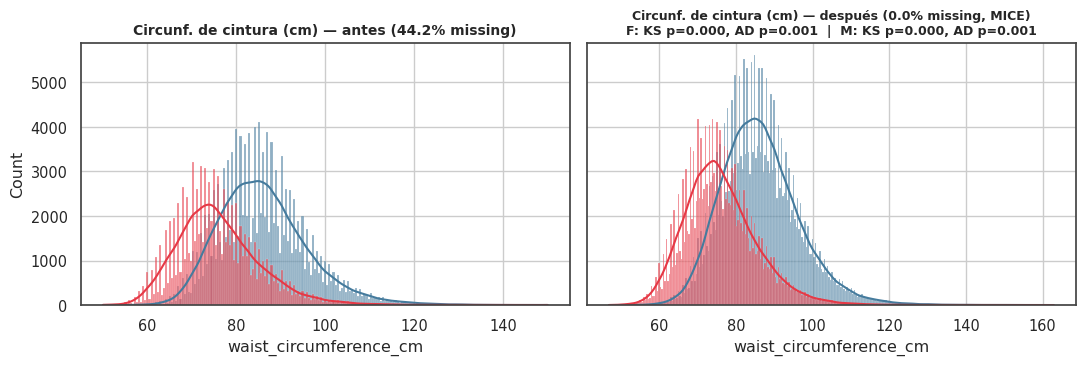

Variables con missing alto imputadas con MICE (IterativeImputer), por género.


In [7]:

# ---------------------------------------------------------------------------
# 5. VARIABLES CON MISSING ALTO — IMPUTACIÓN CON MICE (conjunta, luego graficada una por una)
# ---------------------------------------------------------------------------
predictor_cols = ["age", "height_cm", "weight_kg", "bmi", "sit_and_reach_cm", "cross_situp_count"]
 
# banderas "fue imputado", antes de tocar los valores
for col in moderate_cols:
    df[f"{col}_was_imputed"] = df[col].isna().astype(int)
 
# snapshot "antes" guardado aparte, para poder graficar el contraste después
# (se guarda también gender_code, para poder separar el diagnóstico por género)
snapshot_before = df[moderate_cols + ["gender_code"]].copy()
 
features = predictor_cols + moderate_cols
imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=15, random_state=42, sample_posterior=True)
 
df_male = df[df["gender_code"] == "M"].copy()
df_female = df[df["gender_code"] == "F"].copy()
 
df_male[features] = imputer.fit_transform(df_male[features])
df_female[features] = IterativeImputer(estimator=BayesianRidge(), max_iter=15,
                                        random_state=42,sample_posterior=True).fit_transform(df_female[features])
 
df = pd.concat([df_male, df_female]).sort_index()
 
# Variables discretas de ESTA sección — mismo criterio que en la sección 3:
# lista explícita, no detección automática. Ajusta aquí si alguna de las tres
# variables de MICE resulta ser un conteo entero en tu dataset real.
DISCRETAS_SECCION_5 = []  # ninguna de reaction_time_sec / standing_long_jump_cm /
                           # waist_circumference_cm se espera discreta, pero
                           # puedes agregar el nombre aquí si tu diagnóstico dice lo contrario
 
# --- ahora sí, graficamos antes/después, una variable a la vez, separado por género ---
for col in moderate_cols:
    etiqueta = LABELS_ES.get(col, col)
    pct_before = snapshot_before[col].isna().mean() * 100
 
    resultados_texto = []
    for genero in ["F", "M"]:
        valores_antes_g = snapshot_before.loc[snapshot_before["gender_code"] == genero, col].dropna().values
        valores_despues_g = df.loc[df["gender_code"] == genero, col].values
 
        if col in DISCRETAS_SECCION_5:
            bins = np.histogram_bin_edges(np.concatenate([valores_antes_g, valores_despues_g]), bins=10)
            conteo_antes, _ = np.histogram(valores_antes_g, bins=bins)
            conteo_despues, _ = np.histogram(valores_despues_g, bins=bins)
            tabla = np.array([conteo_antes, conteo_despues]) + 1e-6
            chi2_stat, chi_p, dof, _ = stats.chi2_contingency(tabla)
            resultados_texto.append(f"{genero}: Chi² p={chi_p:.3f}")
        else:
            ks_stat, ks_p = stats.ks_2samp(valores_antes_g, valores_despues_g)
            ad_result = stats.anderson_ksamp([valores_antes_g, valores_despues_g])
            ad_p = ad_result.significance_level
            resultados_texto.append(f"{genero}: KS p={ks_p:.3f}, AD p={ad_p:.3f}")
 
    titulo_prueba = "  |  ".join(resultados_texto)
 
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
 
    sns.histplot(data=snapshot_before, x=col, hue="gender_code", palette=PALETA_GENERO,
                 kde=True, ax=axes[0], alpha=0.6, legend=False)
    axes[0].set_title(f"{etiqueta} — antes ({pct_before:.1f}% missing)", fontsize=10)
 
    sns.histplot(data=df, x=col, hue="gender_code", palette=PALETA_GENERO,
                 kde=True, ax=axes[1], alpha=0.6, legend=False)
    axes[1].set_title(
        f"{etiqueta} — después (0.0% missing, MICE)\n{titulo_prueba}",
        fontsize=9,
    )
 
    plt.tight_layout()
    plt.show()
 
print("Variables con missing alto imputadas con MICE (IterativeImputer), por género.")
 

Las pruebas de hipotesis infieren que la distribución no ha cambiado, por lo que la estrategia funciona correctamente.

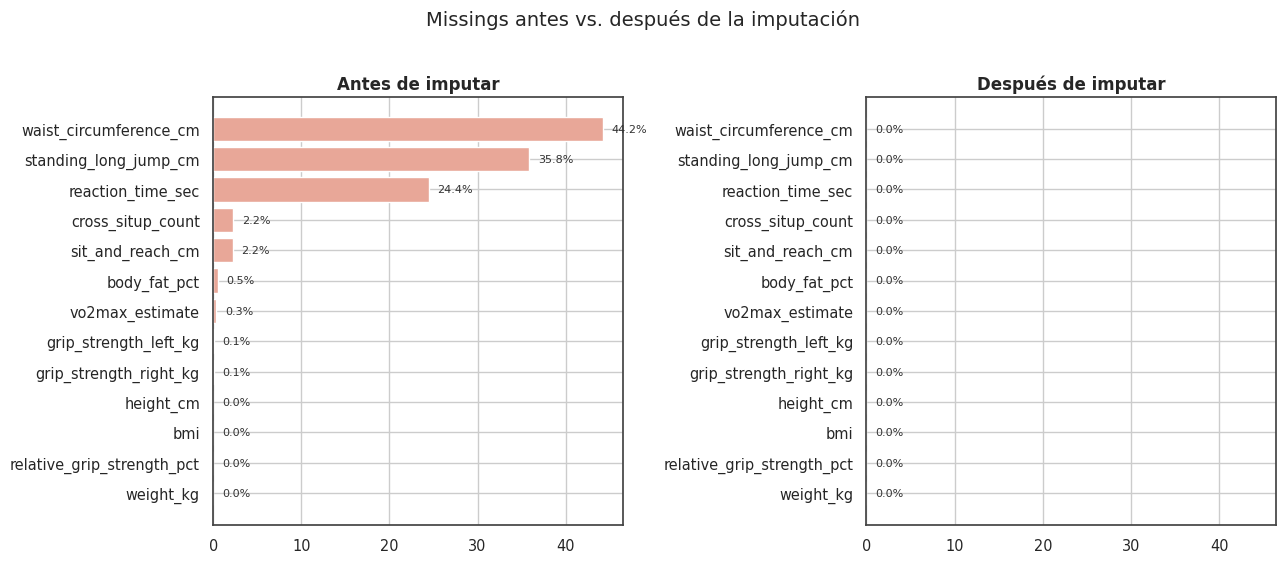

In [8]:
# ---------------------------------------------------------------------------
# 6. PANORAMA GENERAL DE MISSINGS (DESPUÉS) — COMPARAR CONTRA EL PASO 2
# ---------------------------------------------------------------------------
missing_after = (df[core_cols].isna().mean() * 100).sort_values(ascending=False)
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True)
 
bars0 = axes[0].barh(missing_before.index, missing_before.values, color=COLOR_BEFORE, edgecolor="white")
axes[0].set_title("Antes de imputar", fontsize=12)
axes[0].invert_yaxis()
 
bars1 = axes[1].barh(missing_after.reindex(missing_before.index).index,
                      missing_after.reindex(missing_before.index).values,
                      color=COLOR_AFTER, edgecolor="white")
axes[1].set_title("Después de imputar", fontsize=12)
axes[1].invert_yaxis()
 
for ax_bars, ax in zip([bars0, bars1], axes):
    for bar in ax_bars:
        val = bar.get_width()
        ax.text(val + 1, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%",
                va="center", fontsize=8, color="#333333")
 
fig.suptitle("Missings antes vs. después de la imputación", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
 

Parquet imputado y completamente limpio listo para usarse

In [9]:

# ---------------------------------------------------------------------------
# 7. GUARDAR RESULTADO FINAL
# ---------------------------------------------------------------------------
df.to_parquet("../Data/processed/fitness_measurements_adult_imputed.parquet", index=False)
print("Dataset final guardado como fitness_measurements_adult_imputed.parquet")

Dataset final guardado como fitness_measurements_adult_imputed.parquet
